In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
from scipy.stats import chi2

import src.data_loader as dl
from src.datasets import LatLonData, XYData, merge, project_latlon_data
from src.preclustering import precluster_latlon_boxes
from src.density_clustering import density_clustering
from src.gmm import gmm
from src.utils import min_enclosing_cap
from src.plotting import generate_folium_map, plot_data

## Load data

In [2]:
filepath = 'example 2 months rot.csv'
df, nans = dl.load_data(filepath)

/home/sputnik/Documents/programming/ElRed/src/data_loader.py:25: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


In [3]:
# Create dict of ElNots + counts, sorted in descending order

elnots = df['elnot']
elnots, counts = np.unique(elnots, return_counts=True)
elnots = {elnot: int(count) for elnot, count in zip(elnots, counts)}
elnots = dict(sorted(elnots.items(), key=lambda item: item[1], reverse=True))
print(elnots)

{'B080Q': 298804, 'S962T': 82139, 'P605Z': 50885, 'G560M': 42420, 'S947A': 18038, 'M308A': 11007, 'V130A': 10191, 'V002E': 7859, 'Y330P': 7540, 'B881R': 7223, 'L325V': 7182, 'K346S': 5979, 'B544O': 5950, 'K817T': 5723, 'C627U': 5479, 'E512N': 4455, 'V159N': 4414, 'G283O': 4289, 'K822L': 3964, 'P820B': 3937, 'O359O': 3889, 'M157Z': 3820, 'R071I': 3647, 'R485C': 3162, 'C781J': 3066, 'I972Z': 3044, 'J467Q': 2982, 'T407X': 2619, 'B674L': 2402, 'O106R': 2334, 'P526R': 2203, 'G820R': 2139, 'N748F': 1971, 'Q970N': 1819, 'Y745R': 1746, 'M379G': 1664, 'J058K': 1660, 'K487S': 1524, 'F630D': 1516, 'G138R': 1459, 'E559U': 1264, 'N576W': 1247, 'D045M': 1177, 'V768J': 1073, 'R600F': 955, 'C178S': 827, 'R649W': 826, 'Q556G': 823, 'Y701U': 776, 'O591P': 763, 'L223L': 753, 'Z367E': 727, 'N735C': 709, 'D948S': 687, 'H091Z': 654, 'W381Q': 640, 'W391W': 613, 'U070H': 428, 'Y709M': 382, 'U898I': 367, 'M896V': 363, 'X007R': 342, 'Y275N': 342, 'K849S': 326, 'N531U': 310, 'H856B': 243, 'Y606H': 229, 'H603M': 

### Load elnot subset as `LatLonData` instance

In [4]:
elnot = 'B080Q'
# elnot = 'J349D'
data = df[df['elnot'] == elnot]
latlons, ellipses = dl.extract_arrays(data, names=['latlons', 'ellipses'])

data = LatLonData(latlons, ellipses, 
                  idx=data.index.astype(int))


## Precluster 1
### Split per bounding boxes connected components

In [5]:
zones, _ = precluster_latlon_boxes(data, check_overlap=True)

In [6]:
# Analyze zones
split_zone_lengths = [len(zone) for zone in zones]
zone_radii = [min_enclosing_cap(zone.latlons)[1] for zone in zones]
zone_radii = ', '.join([f"{r:.2f}" for r in zone_radii])

print(f"\nAfter initial split into {len(zones)} zones by bbox overlap:")
print(f"Zone sizes [# points]: {split_zone_lengths}")
print(f"Zone radii [degrees]: {zone_radii}")


After initial split into 342 zones by bbox overlap:
Zone sizes [# points]: [295089, 2751, 167, 158, 71, 24, 20, 12, 10, 8, 7, 7, 5, 5, 5, 5, 5, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

## Generate folium maps html files
Too large datasets take some time to generate and might crash your browser when opening.

In [7]:
# merged_data = merge(zones)
# # Create dir if not exists: maps
# import os
# if not os.path.exists('maps'):
#     os.makedirs('maps')

# m = generate_folium_map(merged_data, mode='bbox', tiles=None)
# m.save('maps/bbox.html')

# m = generate_folium_map(merged_data, mode='ellipse', tiles=None)
# m.save('maps/ellipses.html')

# m = generate_folium_map(zones[0], mode='points')
# m.save('maps/zone_1.html')

## Projection
Project zone to 2D data (`XYData` instance) and plotting\
Note: Plotting ellipses for large datasets takes some time

In [8]:
xy_zones = [project_latlon_data(zone) for zone in zones]

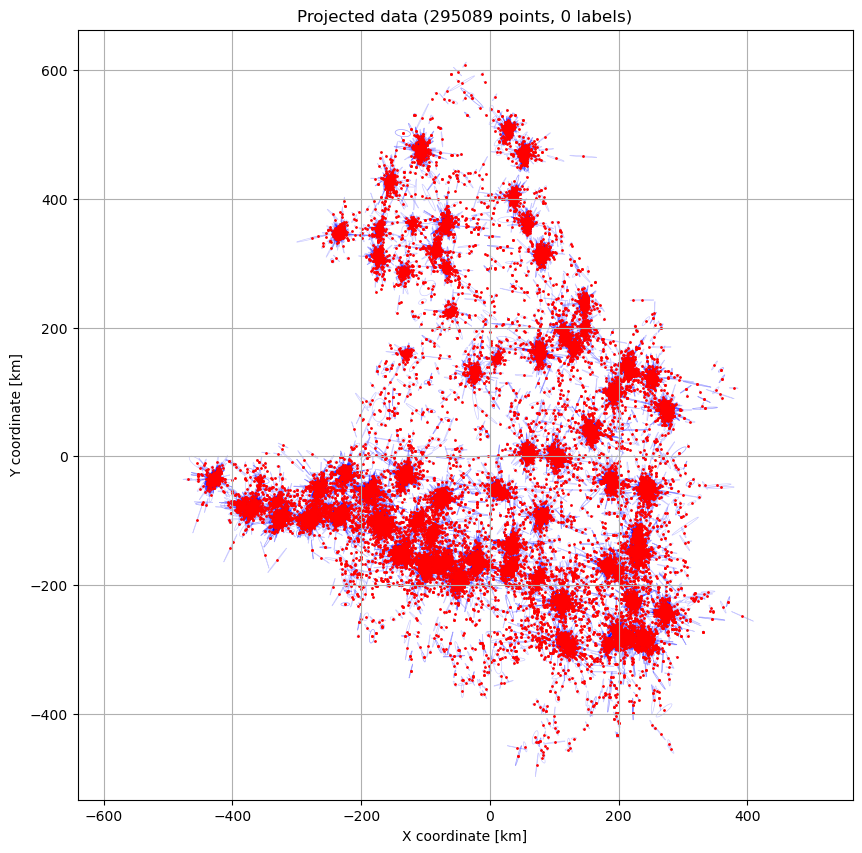

In [9]:
plt = plot_data(xy_zones[0], show_ellipses=True)
plt.show()

In [10]:
testset = xy_zones[0]
subsets, outliers, peaks = density_clustering(testset, 
                                              min_dist_between_peaks=700,
                                              sigma_in_meters=1000,
                                              threshold_count_per_km2=400,
                                              verbose=True,
                                              outliers_subgroup_tol=0)

labeled_testset = XYData.merge(subsets)

Grid shape: (3318, 4186), max count: 903
Grid cell size: 259.8076171875 meters
Gaussian sigma: 3.85 cells
Count threshold: 27.0
Min distance between peaks: 2 cells (519.6 meters)
Found 309 blobs, 296 subsets, 24634 outliers


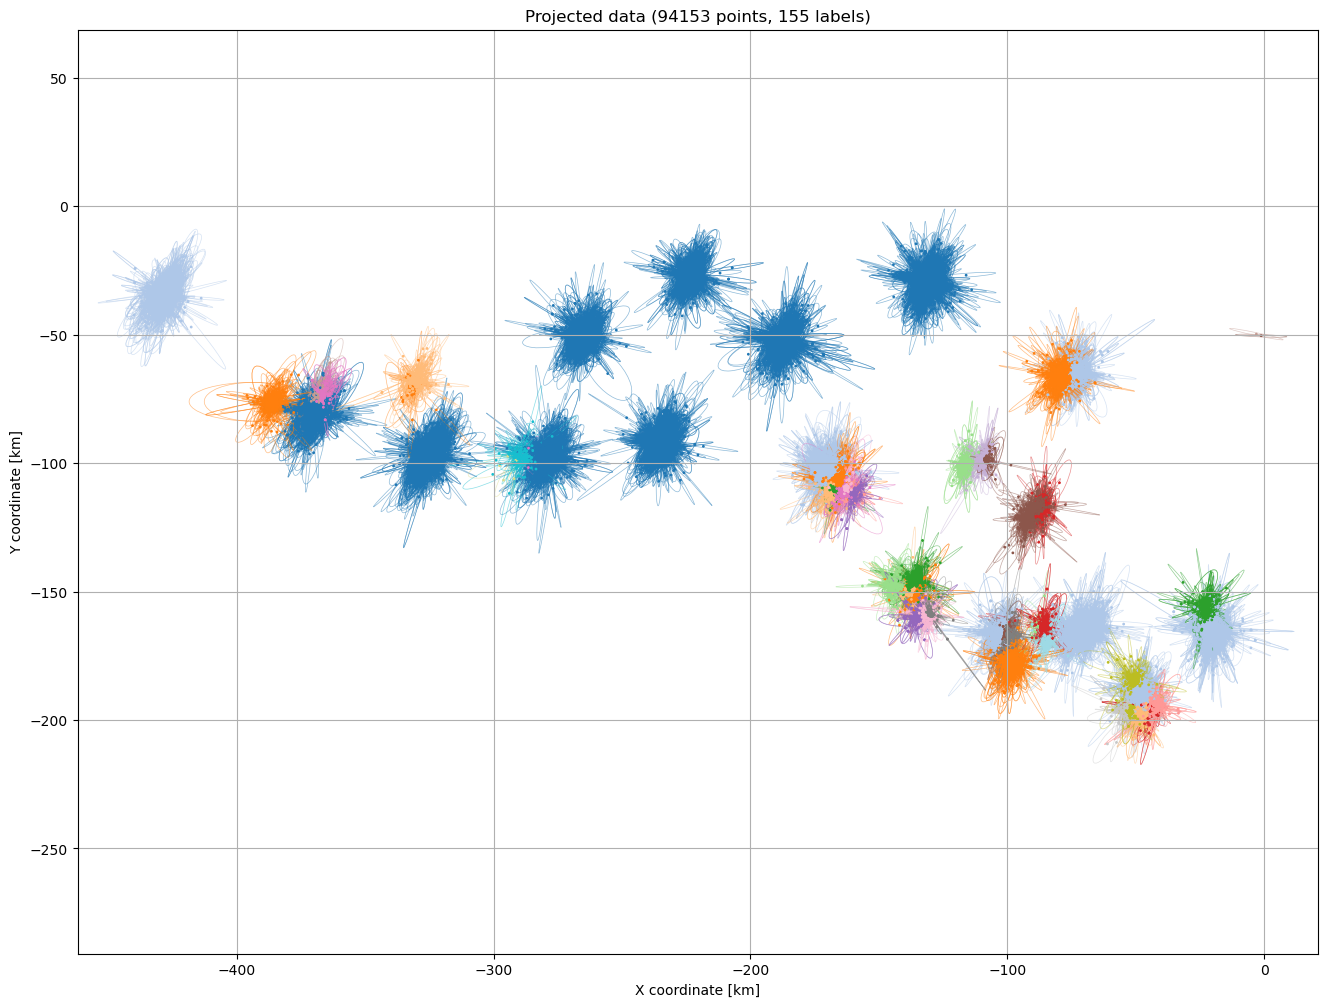

In [11]:
selected_labels = [1,3,4,5,6,8,140]

to_plot = labeled_testset.extract_bounding_box(x_max=0, y_max=0)
# to_plot = to_plot[np.isin(to_plot.labels, selected_labels)]

plot_data(to_plot, show_ellipses=True, figsize=(16,12), ellipses_alpha=.5)
# plt.scatter(peaks[:,0]/1000, peaks[:,1]/1000, c='red', s=200, marker='x', label='Blob centers')

# plot_data(outliers, show_ellipses=True, figsize=(16,12), ellipses_alpha=.5)


# plt.xlim(-55, -46)
# plt.ylim(-192, -182)
plt.show()

In [15]:
folium_data = data.get_by_index(to_plot.idx)

In [21]:
# 1. Get the indices that would sort A.idx
sorter = np.argsort(to_plot.idx)

# 2. Find the positions of B.idx elements within the sorted A.idx
#    This gives us an array of indices that maps B.idx to the sorted A.idx
positions = np.searchsorted(to_plot.idx, folium_data.idx, sorter=sorter)

# 3. Use the sorter to get the final indices into the original A.labels
final_indices = sorter[positions]

# 4. Assign the correctly ordered labels from A to B
folium_data.labels = to_plot.labels[final_indices]

In [23]:
m = generate_folium_map(folium_data, mode='points', ellipse_num_points=12)
m.save('maps/labeled_set_points.html')

## Second split
Compute weighted graph based on pairwise mahalanobis distances and split into connected components.

In [ ]:
import cProfile
import pstats

In [ ]:
pr = cProfile.Profile()
pr.enable()
subset.split_into_connected_components()
pr.disable()

In [ ]:
stats = pstats.Stats(pr)
stats.sort_stats('cumulative')
stats.print_stats(20)

In [ ]:
len(subset)

## Final clustering
1. Spectral clustering for K (# clusters) and first labels assignment. This one reuses the previously computed graph
2. Adapted GMM for fine-tuned output.

In [ ]:
gmm_sets = []
for gmm_set in subset.split_by_labels():
    gmm_set.spectral_clustering()
    gmm(gmm_set)
    gmm_sets.append(gmm_set)

subset = XYData.merge(gmm_sets)

In [ ]:
plot_data(subset, figsize=(16,9), show_ellipses=True)

In [ ]:
subset.labels